In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

import numpy as np

Last run: 2026-03-30 11:36:37


In [23]:
df = pd.read_pickle("obituaries_lemma.pkl")
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 215160 entries, 0 to 215159
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   url                    215160 non-null  str           
 1   date                   215160 non-null  datetime64[us]
 2   biography              215160 non-null  str           
 3   gender                 215160 non-null  str           
 4   bio                    198981 non-null  str           
 5   life                   210888 non-null  str           
 6   family                 198787 non-null  str           
 7   memorial               130509 non-null  str           
 8   life_no_names_numbers  215160 non-null  str           
 9   text_clean             215160 non-null  str           
 10  year                   215160 non-null  int32         
dtypes: datetime64[us](1), int32(1), str(9)
memory usage: 17.2 MB
Last run: 2026-03-30 11:44:39


# Document Distribution by Gender

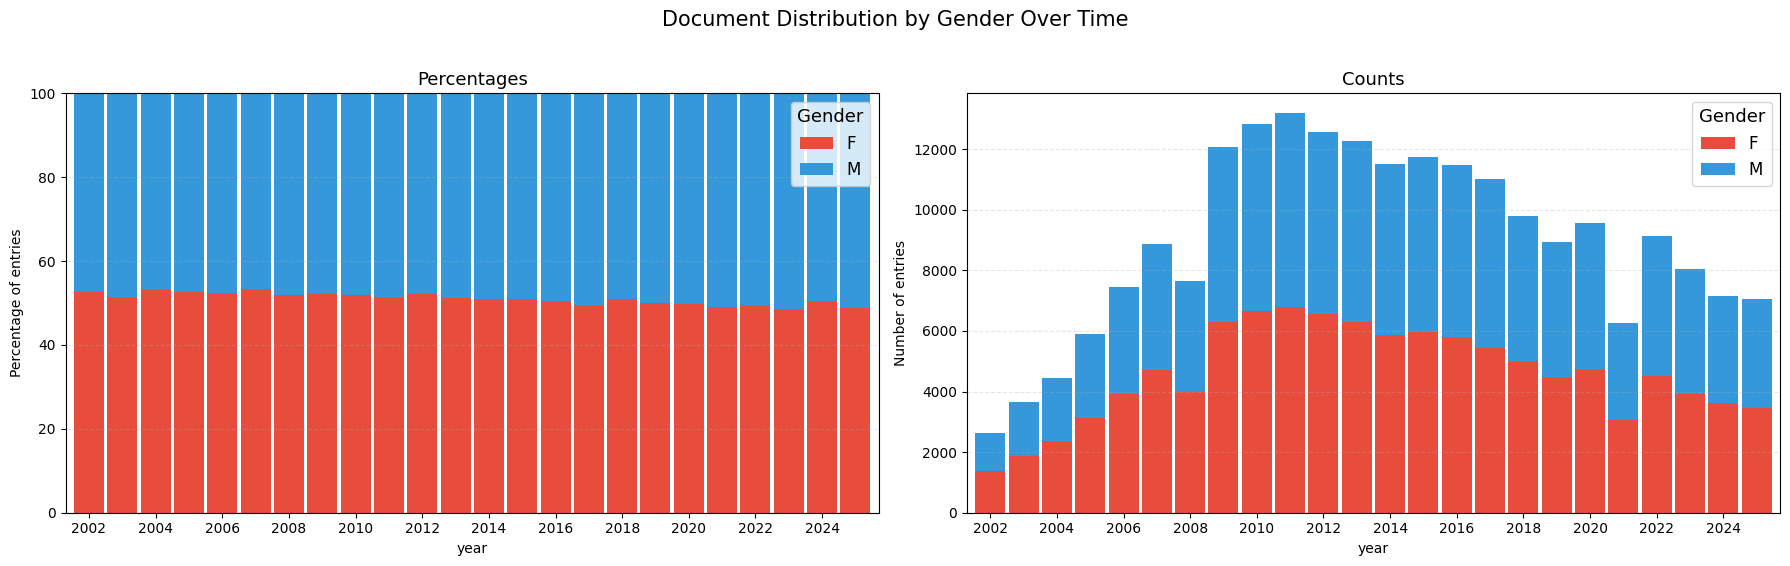

Last run: 2026-03-30 11:57:57


In [35]:
counts = (
    df.groupby(['year', 'gender'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=['F', 'M'], fill_value=0)
      .sort_index()
)

percentages = counts.div(counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5), sharey=False)

percentages.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=['#e74c3c', '#3498db'],
    width=0.9
)
axes[0].set_title('Percentages', fontsize=13)
axes[0].set_ylabel('Percentage of entries')
axes[0].legend(title='Gender', loc='upper right', fontsize=12, title_fontsize=13)
axes[0].set_ylim(0, 100)

counts.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['#e74c3c', '#3498db'],
    width=0.9
)
axes[1].set_title('Counts', fontsize=13)
axes[1].set_ylabel('Number of entries')
axes[1].legend(title='Gender', loc='upper right', fontsize=12, title_fontsize=13)

visible_years = counts.index[::2]
tick_positions = list(range(0, len(counts.index), 2))

for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(visible_years, rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle('Document Distribution by Gender Over Time', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('paper/text_dist_per_gender.png', dpi=300)
plt.show()

# Document Length Over Time per gender

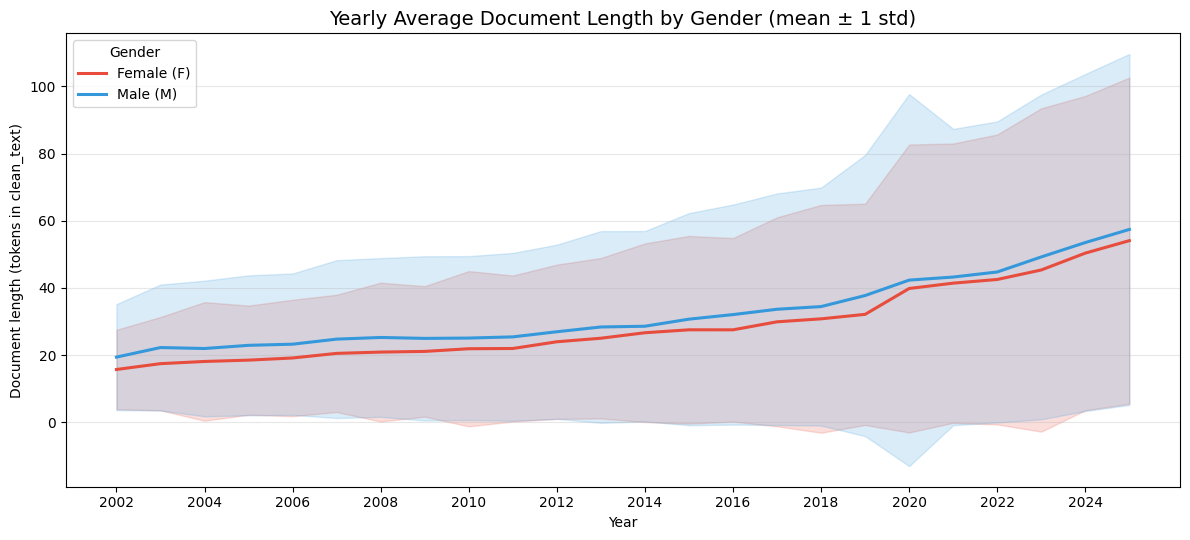

Last run: 2026-03-30 12:15:08


In [47]:
# Measure document length from clean_text as number of whitespace-separated tokens.
df['doc_length'] = df['text_clean'].str.split().str.len()

yearly_stats = (
    df.groupby(['year', 'gender'])['doc_length']
    .agg(mean='mean', std='std')
    .reset_index()
    .sort_values(['gender', 'year'])
)

colors = {'F': '#e74c3c', 'M': '#3498db'}
labels = {'F': 'Female (F)', 'M': 'Male (M)'}

fig, ax = plt.subplots(figsize=(12, 5.5))

for g in ['F', 'M']:
    g_data = yearly_stats[yearly_stats['gender'] == g]
    if g_data.empty:
        continue

    x = g_data['year'].to_numpy()
    y = g_data['mean'].to_numpy()
    s = g_data['std'].fillna(0).to_numpy()

    ax.plot(x, y, color=colors[g], linewidth=2.2,  markersize=4, label=labels[g])
    ax.fill_between(x, y - s, y + s, color=colors[g], alpha=0.18)

ax.set_title('Yearly Average Document Length by Gender (mean ± 1 std)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Document length (tokens in clean_text)')
ax.grid(axis='y',alpha=0.3)
ax.legend(title='Gender')

unique_years = np.sort(yearly_stats['year'].unique())
if len(unique_years) > 0:
    visible_years = unique_years[::2] if len(unique_years) > 12 else unique_years
    ax.set_xticks(visible_years)

plt.tight_layout()
plt.savefig('paper/avg_doc_length_per_gender.png', dpi=300)
plt.show()

# Document Frequency per Word

,word,term_freq,doc_freq
38521,year,193254,114899
12091,family,141299,86371
20084,love,140812,80049
37492,work,104902,77902
37161,wife,125129,76776
11089,enjoy,96246,76748
21178,member,109857,76487
16539,husband,112632,72020
13348,friend,88584,65170
19114,late,84842,60093


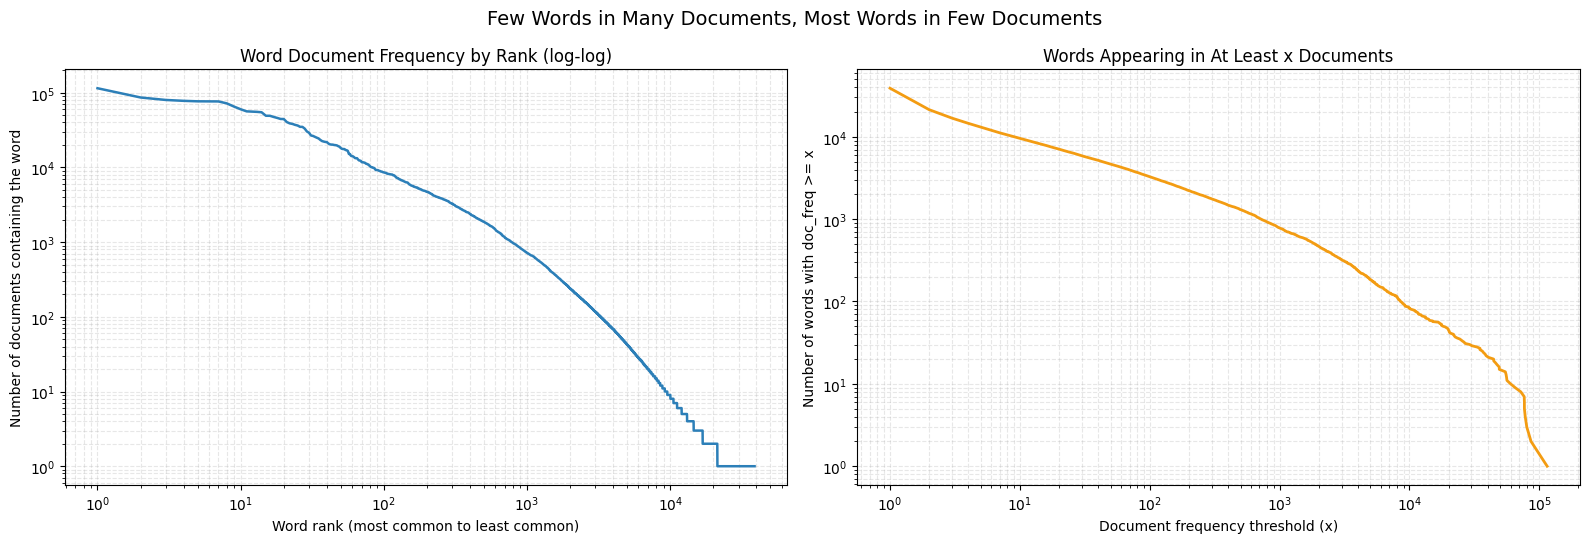

Last run: 2026-03-30 12:25:19


In [50]:
text_col = 'clean_text' if 'clean_text' in df.columns else 'text_clean'

documents = df[text_col].fillna('').astype(str)

vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform(documents)
terms = np.array(vectorizer.get_feature_names_out())

# Term frequency: total number of times each word appears across all documents.
total_terms = np.asarray(dtm.sum(axis=0)).ravel()

# Document frequency: in how many documents each word appears at least once.
doc_counts = np.asarray((dtm > 0).sum(axis=0)).ravel()

freq_df = pd.DataFrame({
    'word': terms,
    'term_freq': total_terms,
    'doc_freq': doc_counts
}).sort_values('doc_freq', ascending=False)

display(freq_df.head(15))

rank = np.arange(1, len(freq_df) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Left: rank-frequency curve (log-log) to show long-tail behavior.
axes[0].plot(rank, freq_df['doc_freq'].to_numpy(), color='#2c7fb8', linewidth=1.8)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Word Document Frequency by Rank (log-log)')
axes[0].set_xlabel('Word rank (most common to least common)')
axes[0].set_ylabel('Number of documents containing the word')
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)

# Right: CCDF-style line plot, similar style to the left panel.
# For each document-frequency threshold x, show how many words appear in at least x documents.
positive_df = freq_df.loc[freq_df['doc_freq'] > 0, 'doc_freq'].to_numpy()
thresholds = np.unique(positive_df)
words_at_least_x = np.array([(positive_df >= t).sum() for t in thresholds])

axes[1].plot(thresholds, words_at_least_x, color='#f39c12', linewidth=2.0)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Words Appearing in At Least x Documents')
axes[1].set_xlabel('Document frequency threshold (x)')
axes[1].set_ylabel('Number of words with doc_freq >= x')
axes[1].grid(True, which='both', linestyle='--', alpha=0.3)

fig.suptitle('Few Words in Many Documents, Most Words in Few Documents', fontsize=14)
plt.tight_layout()
plt.savefig('paper/document_frequency_long_tail.png', dpi=300)
plt.show()

In [52]:
top_n = 10
text_col = 'clean_text' if 'clean_text' in df.columns else 'text_clean'

top_words_by_gender = {}

for g in ['F', 'M']:
    docs = df.loc[df['gender'] == g, text_col].fillna('').astype(str)

    vec = CountVectorizer()
    X = vec.fit_transform(docs)

    words = np.array(vec.get_feature_names_out())
    counts = np.asarray(X.sum(axis=0)).ravel()

    top_df = (
        pd.DataFrame({'word': words, 'count': counts})
        .sort_values('count', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    top_words_by_gender[g] = top_df

print(f'Top {top_n} most common words - Female (F)')
display(top_words_by_gender['F'])

print(f'Top {top_n} most common words - Male (M)')
display(top_words_by_gender['M'])

Top 10 most common words - Female (F)


,word,count
0,year,88798
1,family,77071
2,love,74960
3,wife,63256
4,husband,56500
5,grandchild,51494
6,late,49998
7,member,49722
8,work,48892
9,enjoy,47639


Top 10 most common words - Male (M)


,word,count
0,year,104456
1,love,65852
2,family,64228
3,wife,61873
4,member,60135
5,husband,56132
6,work,56010
7,serve,48921
8,enjoy,48607
9,friend,43646


Last run: 2026-03-30 12:36:32
